# Part B - SALSABILA AURELIA OKTANIOPUTRI
- Q2: Naive Bayes Supervised Text Classification
- Q3: Hyperparameter Tuning 

## Q2. Naive Bayes Sentiment Classification
- This section builds a Naive Bayes text classification model to predict the sentiment of Flipcart product reviews.
- Load preprocessed traina dn test data > convert the text into TD IDF numerical features > train a complement naive bayes classifier > evaluate using accuracy, precision, recall F1, confusion matrix
- complement naive bayes chosen over standard multinomial naive bayes because it performs beter on imbalanced data
 

### 2.1. Install and Import all Required Libraries

In [1]:
# Install any missing libraries
%pip install scikit-learn pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### 2.2. Import Libraries

In [2]:
# Standard library and data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: pipeline, model, vectoriser, evaluation tools
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Apply consistent plot styling from Q1
plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'font.size'          : 12,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'figure.dpi'         : 150,
})

print('=== LIBRARIES LOADED SUCCESSFULLY ===')

=== LIBRARIES LOADED SUCCESSFULLY ===


### 2.3. Load Train & Test Sets

In [3]:
# Load the preprocessed train and test datasets
train_df = pd.read_csv('../Data/train_set.csv')
test_df  = pd.read_csv('../Data/test_set.csv')

# Separate features (X) and labels (y) for both splits
X_train = train_df['Summary_clean']
y_train = train_df['Sentiment']

X_test  = test_df['Summary_clean']
y_test  = test_df['Sentiment']

# Display a quick confirmation of what was loaded
print('=== DATA LOADED ===')
print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'\nClass distribution — Train:')
print(y_train.value_counts().to_string())
print(f'\nClass distribution — Test:')
print(y_test.value_counts().to_string())

=== DATA LOADED ===
Training samples : 107,768
Test samples     : 26,945

Class distribution — Train:
Sentiment
positive    81835
negative    19791
neutral      6142

Class distribution — Test:
Sentiment
positive    20456
negative     4949
neutral      1540


In [8]:
print(train_df.head())
print("-- Xtrain --")
print(X_train.head())
print("-- Ytrain --")
print(y_train.head())

                                       Summary_clean Sentiment
0  good product beautiful sound good packing chea...  positive
1    shown picture soft cute baby dress really liked  positive
2    great deal niece cloud nine quality also superb  positive
3  superb productthis second washing machine marq...  positive
4                            dam masti like prodocts  positive
-- Xtrain --
0    good product beautiful sound good packing chea...
1      shown picture soft cute baby dress really liked
2      great deal niece cloud nine quality also superb
3    superb productthis second washing machine marq...
4                              dam masti like prodocts
Name: Summary_clean, dtype: str
-- Ytrain --
0    positive
1    positive
2    positive
3    positive
4    positive
Name: Sentiment, dtype: str


### 2.4. Build and Train the Naive Bayes Pipeline

In [9]:
# Build a pipeline: TF-IDF vectoriser → Complement Naive Bayes classifier
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 30000,   # Limit vocabulary to top 30,000 terms
        ngram_range  = (1, 2),  # Use unigrams and bigrams
        min_df       = 2,       # Ignore terms appearing in fewer than 2 docs
        sublinear_tf = True     # Apply log scaling to term frequencies
    )),
    ('clf', ComplementNB(
        alpha = 1.0,            # Default Laplace smoothing
        norm  = False           # Do not normalise complement weights
    ))
])

# Fit the pipeline on the training data
nb_pipeline.fit(X_train, y_train)

print('=== MODEL TRAINING COMPLETE ===')
print('Model     : Complement Naive Bayes')
print('Vectoriser: TF-IDF (unigrams + bigrams, max 30,000 features)')
print('Status    : Fitted on training set successfully')

=== MODEL TRAINING COMPLETE ===
Model     : Complement Naive Bayes
Vectoriser: TF-IDF (unigrams + bigrams, max 30,000 features)
Status    : Fitted on training set successfully


### 2.5. Generate Prediction on Test Set

In [10]:
# Predict sentiment labels on the test set
y_pred = nb_pipeline.predict(X_test)

# Show a quick sample of actual vs predicted labels
results_sample = pd.DataFrame({
    'Summary'   : X_test.values[:8],
    'Actual'    : y_test.values[:8],
    'Predicted' : y_pred[:8]
})

print('=== PREDICTIONS GENERATED ===')
print(f'Total predictions made: {len(y_pred):,}')
print('\nSample — Actual vs Predicted (first 8 rows):')
print(results_sample.to_string(index=False))

=== PREDICTIONS GENERATED ===
Total predictions made: 26,945

Sample — Actual vs Predicted (first 8 rows):
                                                                         Summary   Actual Predicted
                                                                    good product positive  positive
                                                                 kettle lid good negative  negative
                      good product motorola feel freshness air purifies air mins positive  positive
dont waste money fashionable onlyaccording price ok want something good dont buy negative  negative
                                                            good beautiful watch positive  positive
                                                        quality ok ok good value positive   neutral
                                                          good watch price range positive  positive
                                                                            good positive  po

### 2.6. Classification Report

In [11]:
# Generate full classification report
report = classification_report(y_test, y_pred,
                                target_names=['negative', 'neutral', 'positive'])

# Calculate overall accuracy separately for a clear printout
accuracy = accuracy_score(y_test, y_pred)

print('=== MODEL EVALUATION — CLASSIFICATION REPORT ===')
print(f'\nModel : Complement Naive Bayes (Default Hyperparameters)')
print(f'{"─" * 62}')
print(report)
print(f'{"─" * 62}')
print(f'Overall Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')

=== MODEL EVALUATION — CLASSIFICATION REPORT ===

Model : Complement Naive Bayes (Default Hyperparameters)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.68      0.81      0.74      4949
     neutral       0.46      0.41      0.43      1540
    positive       0.94      0.91      0.92     20456

    accuracy                           0.86     26945
   macro avg       0.69      0.71      0.70     26945
weighted avg       0.87      0.86      0.86     26945

──────────────────────────────────────────────────────────────
Overall Accuracy : 0.8608 (86.08%)


### 2.7. Confusion Matrix Heatmap

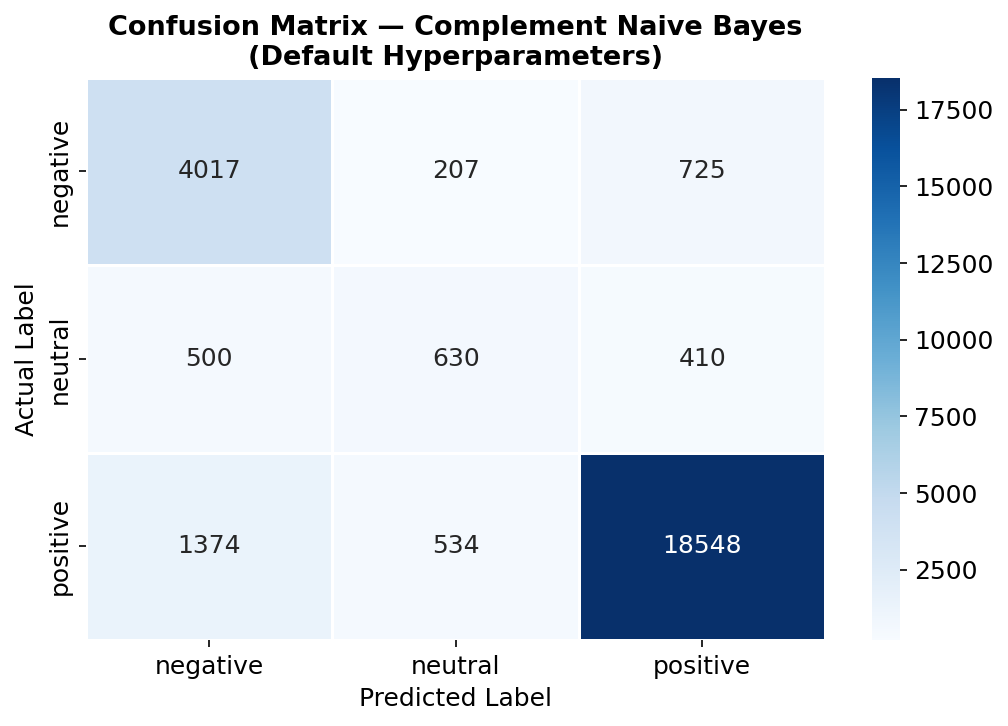


=== CONFUSION MATRIX (RAW VALUES) ===
Predicted  negative  neutral  positive
Actual                                
negative       4017      207       725
neutral         500      630       410
positive       1374      534     18548


In [12]:
# Compute the confusion matrix
LABELS = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=LABELS)

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= LABELS,
    yticklabels= LABELS,
    linewidths = 0.5,
    ax         = ax
)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_title('Confusion Matrix — Complement Naive Bayes\n(Default Hyperparameters)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the raw confusion matrix as a labelled table for the report
print('\n=== CONFUSION MATRIX (RAW VALUES) ===')
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
cm_df.index.name   = 'Actual'
cm_df.columns.name = 'Predicted'
print(cm_df.to_string())

## Q3. Hyperparameter Tuning


### 3.1. Import GridSearchCV

In [13]:
# Import GridSearchCV for exhaustive hyperparameter search
from sklearn.model_selection import GridSearchCV

print('=== GRID SEARCH LIBRARIES LOADED ===')

=== GRID SEARCH LIBRARIES LOADED ===


### 3.2. Define the Parameter Grid
- define all combinations of hyperparameters for the grid search to try

In [14]:
# Define the hyperparameter grid to search over
# Pipeline uses double underscore: stepname__parametername
param_grid = {
    'tfidf__max_features' : [20000, 30000],
    'tfidf__ngram_range'  : [(1, 1), (1, 2)],
    'tfidf__min_df'       : [2, 5],
    'clf__alpha'          : [0.1, 0.5, 1.0, 2.0],
    'clf__norm'           : [True, False]
}

# Calculate total number of combinations being tested
total_combinations = 2 * 2 * 2 * 4 * 2
print('=== HYPERPARAMETER GRID DEFINED ===')
print(f'Parameters being tuned:')
for param, values in param_grid.items():
    print(f'  {param:30s}: {values}')
print(f'\nTotal combinations to test : {total_combinations}')
print(f'Cross-validation folds     : 5')
print(f'Total model fits           : {total_combinations * 5}')
print(f'Scoring metric             : macro F1 (chosen due to class imbalance)')

=== HYPERPARAMETER GRID DEFINED ===
Parameters being tuned:
  tfidf__max_features           : [20000, 30000]
  tfidf__ngram_range            : [(1, 1), (1, 2)]
  tfidf__min_df                 : [2, 5]
  clf__alpha                    : [0.1, 0.5, 1.0, 2.0]
  clf__norm                     : [True, False]

Total combinations to test : 64
Cross-validation folds     : 5
Total model fits           : 320
Scoring metric             : macro F1 (chosen due to class imbalance)


### 3.3. Run the Grid Search
- run the grid search on the training data

In [15]:
# Initialise grid search with the pipeline and parameter grid
grid_search = GridSearchCV(
    estimator  = nb_pipeline,   # The pipeline built in Q2
    param_grid = param_grid,
    cv         = 5,             # 5-fold cross validation
    scoring    = 'f1_macro',    # Optimise for macro F1 — best for imbalanced classes
    n_jobs     = -1,            # Use all CPU cores to speed up search
    verbose    = 1              # Print progress during search
)

print('=== GRID SEARCH RUNNING — PLEASE WAIT ===')
print('Testing 64 combinations × 5 folds = 320 model fits...\n')

# Fit grid search on training data only
grid_search.fit(X_train, y_train)

print('\n=== GRID SEARCH COMPLETE ===')

=== GRID SEARCH RUNNING — PLEASE WAIT ===
Testing 64 combinations × 5 folds = 320 model fits...

Fitting 5 folds for each of 64 candidates, totalling 320 fits

=== GRID SEARCH COMPLETE ===


### 3.4. Report Best Parameters Found

In [16]:
# Extract and display the best parameters and score found
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print('=== BEST HYPERPARAMETERS FOUND ===')
print(f'\nBest cross-validation macro F1 : {best_cv_score:.4f} ({best_cv_score*100:.2f}%)')
print(f'\nBest parameter combination:')
for param, value in best_params.items():
    print(f'  {param:30s}: {value}')

=== BEST HYPERPARAMETERS FOUND ===

Best cross-validation macro F1 : 0.7155 (71.55%)

Best parameter combination:
  clf__alpha                    : 1.0
  clf__norm                     : True
  tfidf__max_features           : 20000
  tfidf__min_df                 : 2
  tfidf__ngram_range            : (1, 2)


### 3.5. Evaluate the Tuned Model

In [17]:
# The best estimator is already refitted on the full training set automatically
best_model = grid_search.best_estimator_

# Predict on test set using the tuned model
y_pred_tuned = best_model.predict(X_test)

# Generate classification report
report_tuned = classification_report(y_test, y_pred_tuned,
                                      target_names=['negative', 'neutral', 'positive'])
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print('=== TUNED MODEL EVALUATION — CLASSIFICATION REPORT ===')
print(f'\nModel : Complement Naive Bayes (Tuned Hyperparameters)')
print(f'{"─" * 62}')
print(report_tuned)
print(f'{"─" * 62}')
print(f'Overall Accuracy : {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)')

=== TUNED MODEL EVALUATION — CLASSIFICATION REPORT ===

Model : Complement Naive Bayes (Tuned Hyperparameters)
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    negative       0.74      0.78      0.76      4949
     neutral       0.52      0.39      0.45      1540
    positive       0.93      0.94      0.94     20456

    accuracy                           0.88     26945
   macro avg       0.73      0.70      0.71     26945
weighted avg       0.87      0.88      0.87     26945

──────────────────────────────────────────────────────────────
Overall Accuracy : 0.8774 (87.74%)


### 3.6. Before and After Tuning Comparison Table

In [18]:
# Store default model metrics from Q2 results
default_metrics = {
    'Accuracy'        : 0.8608,
    'Macro F1'        : 0.70,
    'Negative F1'     : 0.74,
    'Neutral F1'      : 0.43,
    'Positive F1'     : 0.92
}

# Extract tuned model metrics from classification report
from sklearn.metrics import f1_score

tuned_f1_per_class = f1_score(y_test, y_pred_tuned,
                               labels=['negative', 'neutral', 'positive'],
                               average=None)

tuned_metrics = {
    'Accuracy'        : accuracy_tuned,
    'Macro F1'        : f1_score(y_test, y_pred_tuned, average='macro'),
    'Negative F1'     : tuned_f1_per_class[0],
    'Neutral F1'      : tuned_f1_per_class[1],
    'Positive F1'     : tuned_f1_per_class[2]
}

# Build and print comparison table
print('=== BEFORE vs AFTER HYPERPARAMETER TUNING ===')
print(f'\n{"Metric":<20} {"Default":>12} {"Tuned":>12} {"Change":>10}')
print('─' * 56)
for metric in default_metrics:
    default_val = default_metrics[metric]
    tuned_val   = tuned_metrics[metric]
    change      = tuned_val - default_val
    direction   = '▲' if change > 0 else ('▼' if change < 0 else '—')
    print(f'{metric:<20} {default_val:>12.4f} {tuned_val:>12.4f} '
          f'{direction} {abs(change):.4f}')
print('─' * 56)

=== BEFORE vs AFTER HYPERPARAMETER TUNING ===

Metric                    Default        Tuned     Change
────────────────────────────────────────────────────────
Accuracy                   0.8608       0.8774 ▲ 0.0166
Macro F1                   0.7000       0.7133 ▲ 0.0133
Negative F1                0.7400       0.7583 ▲ 0.0183
Neutral F1                 0.4300       0.4466 ▲ 0.0166
Positive F1                0.9200       0.9351 ▲ 0.0151
────────────────────────────────────────────────────────


### 3.7. Tuned Model Confusion Matrix

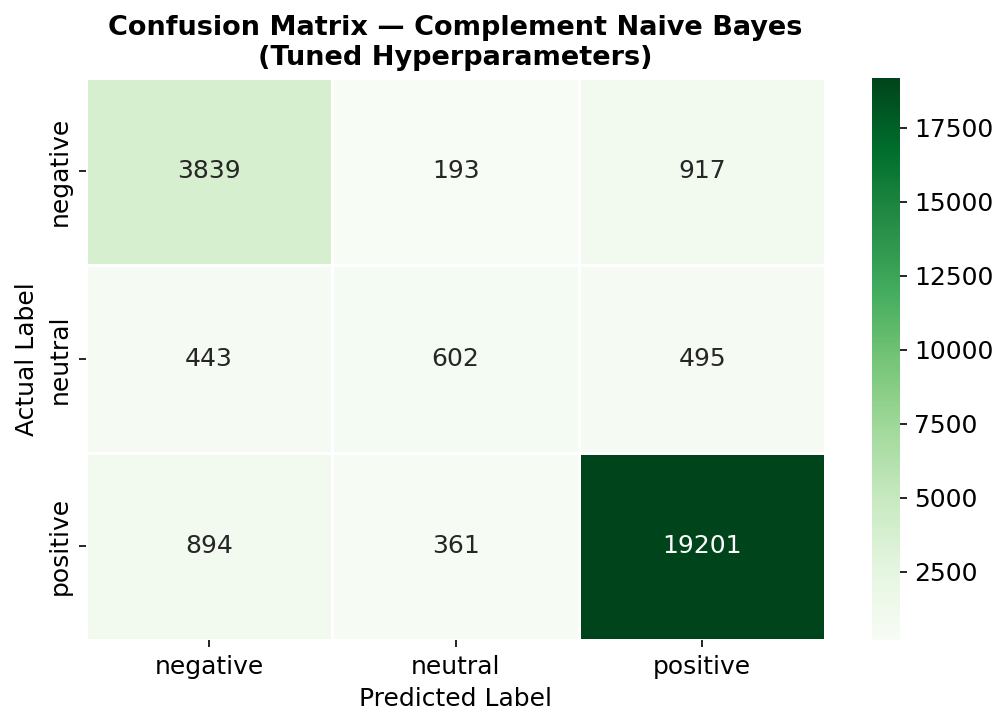


=== TUNED CONFUSION MATRIX (RAW VALUES) ===
Predicted  negative  neutral  positive
Actual                                
negative       3839      193       917
neutral         443      602       495
positive        894      361     19201


In [19]:
# Compute confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=LABELS)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Greens',       # Green to visually distinguish from default (Blue)
    xticklabels= LABELS,
    yticklabels= LABELS,
    linewidths = 0.5,
    ax         = ax
)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label',    fontsize=12)
ax.set_title('Confusion Matrix — Complement Naive Bayes\n(Tuned Hyperparameters)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print raw values
print('\n=== TUNED CONFUSION MATRIX (RAW VALUES) ===')
cm_tuned_df = pd.DataFrame(cm_tuned, index=LABELS, columns=LABELS)
cm_tuned_df.index.name   = 'Actual'
cm_tuned_df.columns.name = 'Predicted'
print(cm_tuned_df.to_string())